# Load data

In [2]:
print('hi')

hi


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [4]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 13

df_raw = pd.read_csv('../data/data.csv', encoding='latin-1')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [10]:
# df shape
print(f'{len(df_raw):,} rows x {df_raw.shape[1]} columns')

541,909 rows x 8 columns


In [13]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [15]:
print('=== Date Range ===')
print(f"{df_raw['InvoiceDate'].min().date()} to {df_raw['InvoiceDate'].max().date()}")

=== Date Range ===
2010-12-01 to 2011-12-09


In [17]:
print('=== Cardinality ===')
for col in ['InvoiceNo','StockCode','Description','CustomerID','Country']:
    print(f'{col}: {df_raw[col].nunique():,} unique')

=== Cardinality ===
InvoiceNo: 25,900 unique
StockCode: 4,070 unique
Description: 4,223 unique
CustomerID: 4,372 unique
Country: 38 unique


In [19]:
print('=== Numeric Summary ===')
display(df_raw[['Quantity','UnitPrice','CustomerID']].describe().round(2))

=== Numeric Summary ===


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


In [22]:
# missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Missing values:')
display(missing_df)

Missing values:


,Missing Count,Missing %
Description,1454,0.27
CustomerID,135080,24.93


In [ ]:
# 24.9% of rows have no CustomerID — these are likely guest/one-off purchases.
# These rows CANNOT be used for customer-level ML (churn, RFM) 
# aka must be excluded or handled separately.

In [26]:
# anomalous transactions
n_cancel   = df_raw['InvoiceNo'].astype(str).str.startswith('C').sum()
n_neg_qty  = (df_raw['Quantity'] < 0).sum()
n_neg_price= (df_raw['UnitPrice'] < 0).sum()
n_zero_price=(df_raw['UnitPrice'] == 0).sum()
n_adj      = df_raw['StockCode'].astype(str).str.upper().isin(['POST','D','DOT','M','S','AMAZONFEE','BANK CHARGES']).sum()

print('=== Anomalous Transactions ===')
print(f'Cancellation invoices (InvoiceNo starts with C): {n_cancel:,}')
print(f'Negative quantity rows (returns/adjustments):    {n_neg_qty:,}')
print(f'Negative price rows:                             {n_neg_price:,}')
print(f'Zero price rows:                                 {n_zero_price:,}')
print(f'Non-product SKUs (POST, BANK CHARGES, etc.):     {n_adj:,}')
print()
print('Cancellation rate (by row):', round(n_cancel / len(df_raw) * 100, 2), '%')

=== Anomalous Transactions ===
Cancellation invoices (InvoiceNo starts with C): 9,288
Negative quantity rows (returns/adjustments):    10,624
Negative price rows:                             2
Zero price rows:                                 2,515
Non-product SKUs (POST, BANK CHARGES, etc.):     2,749

Cancellation rate (by row): 1.71 %


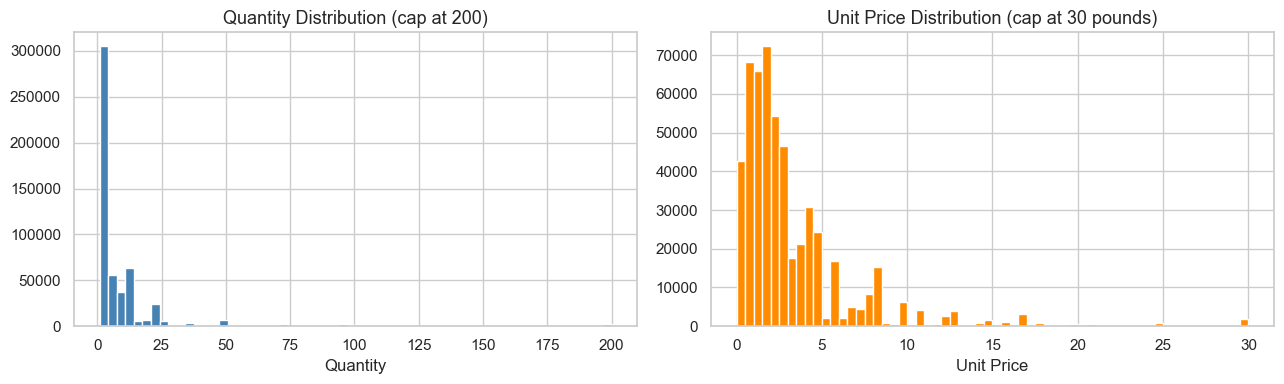

99th percentile Quantity: 100.0
99th percentile UnitPrice: 16.98

Max Quantity: 80995 | Max Price: gbp 38970.0


In [31]:
# Outlier detection
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_pos = df_raw[(df_raw['Quantity'] > 0) & (df_raw['UnitPrice'] > 0)]

axes[0].hist(df_pos['Quantity'].clip(upper=200), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Quantity Distribution (cap at 200)')
axes[0].set_xlabel('Quantity')

axes[1].hist(df_pos['UnitPrice'].clip(upper=30), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Unit Price Distribution (cap at 30 pounds)')
axes[1].set_xlabel('Unit Price')

plt.tight_layout()
# plt.savefig('../project/fig_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

q99_qty   = df_pos['Quantity'].quantile(0.99)
q99_price = df_pos['UnitPrice'].quantile(0.99)
print(f'99th percentile Quantity: {q99_qty}')
print(f'99th percentile UnitPrice: {q99_price:.2f}')
print()
print('Max Quantity:', df_raw['Quantity'].max(), '| Max Price: gbp', df_raw['UnitPrice'].max())

# Temporal analysis

In [36]:
# clean df? 
### might vary depending on how we clean
df = df_raw.copy()
df['is_cancel'] = df['InvoiceNo'].astype(str).str.startswith('C')
df_clean = df[
    ~df['is_cancel'] &
    df['CustomerID'].notna() &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['Hour']      = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
print(f'Clean dataset: {len(df_clean):,} rows, {df_clean["CustomerID"].nunique():,} customers')

Clean dataset: 397,884 rows, 4,338 customers


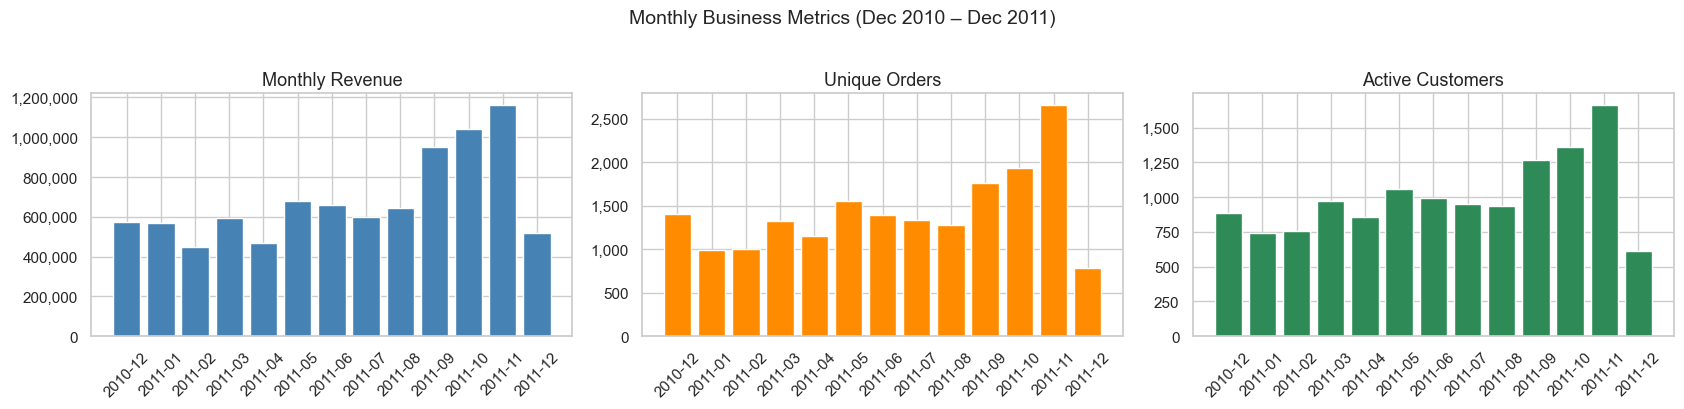

Peak month (Revenue): 2011-11 1,161,817 pounds


In [39]:
# Monthly revenue trend
monthly_rev = df_clean.groupby('YearMonth').agg(
    Revenue=('Revenue','sum'),
    Orders=('InvoiceNo','nunique'),
    Customers=('CustomerID','nunique')
).reset_index()
monthly_rev['YearMonth_str'] = monthly_rev['YearMonth'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, col, label, color in zip(
    axes,
    ['Revenue','Orders','Customers'],
    ['Monthly Revenue','Unique Orders','Active Customers'],
    ['steelblue','darkorange','seagreen']
):
    ax.bar(monthly_rev['YearMonth_str'], monthly_rev[col], color=color)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Monthly Business Metrics (Dec 2010 – Dec 2011)', y=1.02, fontsize=14)
plt.tight_layout()
# plt.savefig('../project/fig_monthly_trends.png', dpi=100, bbox_inches='tight')
plt.show()

print('Peak month (Revenue):', monthly_rev.loc[monthly_rev['Revenue'].idxmax(), 'YearMonth_str'],
      f"{monthly_rev['Revenue'].max():,.0f} pounds")

In [ ]:
# dec partial month
# Q4 sees higher sales etc -> seasonality?

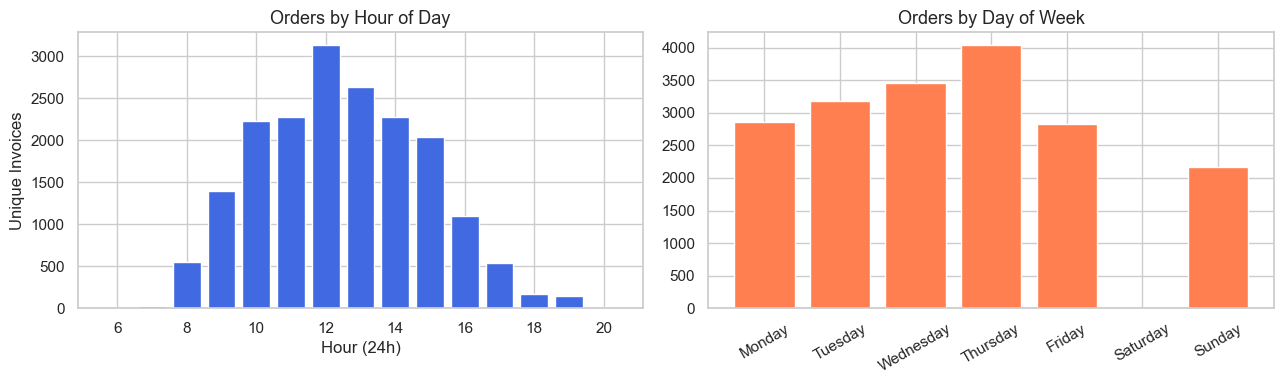

In [42]:
# intra day and day-of-week patterns
hourly = df_clean.groupby('Hour')['InvoiceNo'].nunique()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily  = df_clean.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(hourly.index, hourly.values, color='royalblue')
axes[0].set_title('Orders by Hour of Day')
axes[0].set_xlabel('Hour (24h)')
axes[0].set_ylabel('Unique Invoices')

axes[1].bar(daily.index, daily.fillna(0).values, color='coral')
axes[1].set_title('Orders by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
# plt.savefig('../project/fig_temporal_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# findings:
# Orders concentrated 9am–5pm, peak at noon → B2B ordering behaviour
# NO Saturday orders → confirms B2B wholesale (not retail consumers)
# Sunday has some activity (likely automated orders or international time zones)

# Geographic analysis

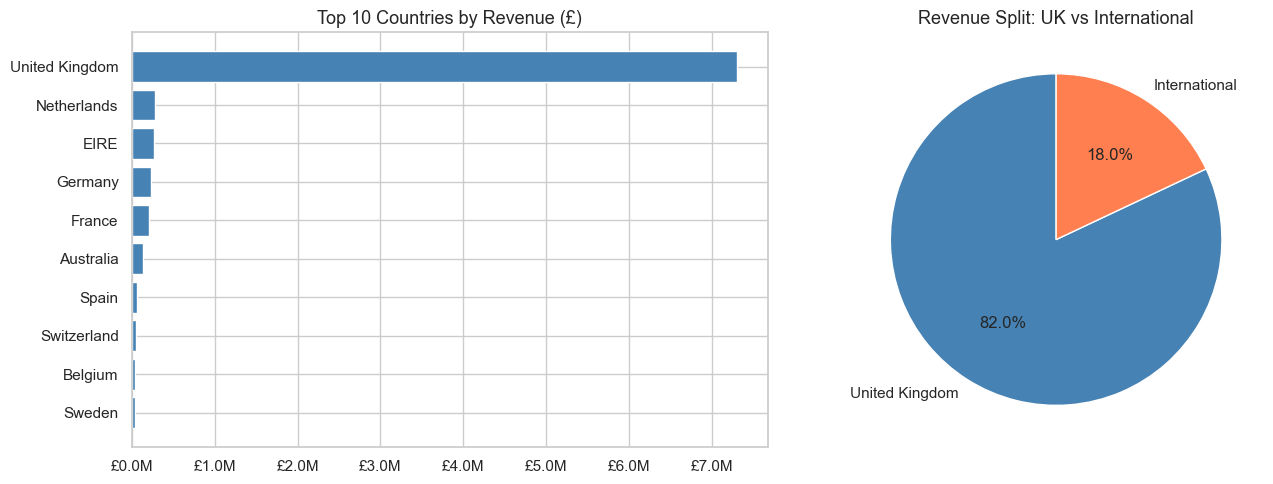

                    Revenue  Orders  Customers  Revenue_pct
Country                                                    
United Kingdom  7308391.554   16646       3920        82.01
Netherlands      285446.340      94          9         3.20
EIRE             265545.900     260          3         2.98
Germany          228867.140     457         94         2.57
France           209024.050     389         87         2.35
Australia        138521.310      57          9         1.55
Spain             61577.110      90         30         0.69
Switzerland       56443.950      51         21         0.63
Belgium           41196.340      98         25         0.46
Sweden            38378.330      36          8         0.43


In [47]:
geo = df_clean.groupby('Country').agg(
    Revenue=('Revenue','sum'),
    Orders=('InvoiceNo','nunique'),
    Customers=('CustomerID','nunique')
).sort_values('Revenue', ascending=False)

geo['Revenue_pct'] = (geo['Revenue'] / geo['Revenue'].sum() * 100).round(2)

top10_geo = geo.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_geo.index[::-1], top10_geo['Revenue'][::-1], color='steelblue')
axes[0].set_title('Top 10 Countries by Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))

# uk vs non uk
uk_rev     = geo.loc['United Kingdom','Revenue']
nonuk_rev  = geo.drop('United Kingdom')['Revenue'].sum()
axes[1].pie([uk_rev, nonuk_rev],
            labels=['United Kingdom','International'],
            autopct='%1.1f%%', colors=['steelblue','coral'],
            startangle=90)
axes[1].set_title('Revenue Split: UK vs International')

plt.tight_layout()
# plt.savefig('../project/fig_geography.png', dpi=100, bbox_inches='tight')
plt.show()

print(geo[['Revenue','Orders','Customers','Revenue_pct']].head(10).to_string())

# Customer analysis

In [51]:
cust = df_clean.groupby('CustomerID').agg(
    Orders     = ('InvoiceNo','nunique'),
    Revenue    = ('Revenue','sum'),
    Items      = ('Quantity','sum'),
    FirstOrder = ('InvoiceDate','min'),
    LastOrder  = ('InvoiceDate','max')
).reset_index()

cust['AvgOrderValue'] = cust['Revenue'] / cust['Orders']
cust['TenureDays']   = (cust['LastOrder'] - cust['FirstOrder']).dt.days

print('=== Customer Summary ===')
display(cust[['Orders','Revenue','AvgOrderValue','TenureDays']].describe().round(2))
print()
print(f"Single-purchase customers: {(cust['Orders']==1).sum():,} ({(cust['Orders']==1).mean()*100:.1f}%)")
print(f"Customers with 5+ orders:  {(cust['Orders']>=5).sum():,} ({(cust['Orders']>=5).mean()*100:.1f}%)")

=== Customer Summary ===


,Orders,Revenue,AvgOrderValue,TenureDays
count,4338.00,4338.00,4338.00,4338.00
mean,4.27,2054.27,419.17,130.45
std,7.70,8989.23,1796.54,132.04
min,1.00,3.75,3.45,0.00
25%,1.00,307.41,178.62,0.00
50%,2.00,674.48,293.90,92.50
75%,5.00,1661.74,430.11,251.75
max,209.00,280206.02,84236.25,373.00



Single-purchase customers: 1,493 (34.4%)
Customers with 5+ orders:  1,114 (25.7%)


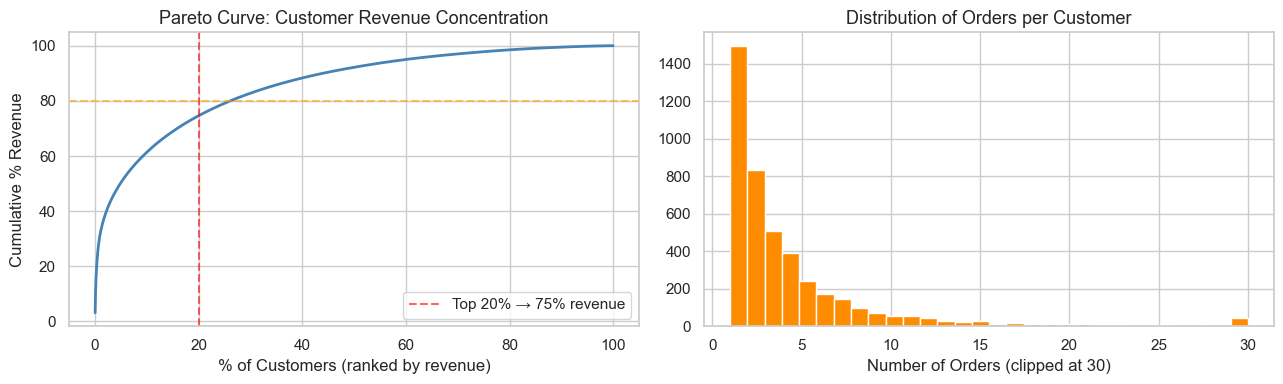

In [54]:
# Customer revenue concentration (pareto stuffs)
cust_sorted = cust.sort_values('Revenue', ascending=False).reset_index(drop=True)
cust_sorted['CumRevPct'] = cust_sorted['Revenue'].cumsum() / cust_sorted['Revenue'].sum() * 100
cust_sorted['CustPct']   = (cust_sorted.index + 1) / len(cust_sorted) * 100

top20_rev = cust_sorted[cust_sorted['CustPct'] <= 20]['CumRevPct'].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cust_sorted['CustPct'], cust_sorted['CumRevPct'], color='steelblue', lw=2)
axes[0].axvline(20, color='red', linestyle='--', alpha=0.6, label=f'Top 20% → {top20_rev:.0f}% revenue')
axes[0].axhline(80, color='orange', linestyle='--', alpha=0.6)
axes[0].set_xlabel('% of Customers (ranked by revenue)')
axes[0].set_ylabel('Cumulative % Revenue')
axes[0].set_title('Pareto Curve: Customer Revenue Concentration')
axes[0].legend()

axes[1].hist(cust['Orders'].clip(upper=30), bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Orders per Customer')
axes[1].set_xlabel('Number of Orders (clipped at 30)')

plt.tight_layout()
# plt.savefig('../project/fig_customer_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Others (more product focused, may be less relevant for customer level)

## Product analysis

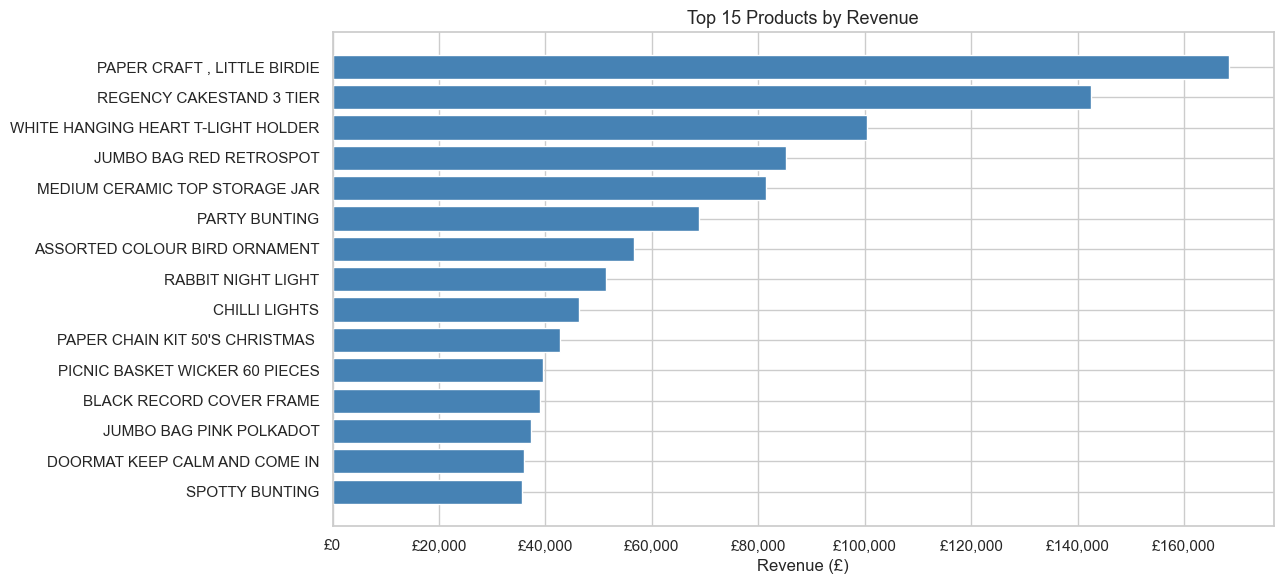

Total unique SKUs (clean): 3,892
Top 100 products = 32.3% of revenue


In [59]:
# top products by revenue
prod = df_clean.groupby(['StockCode','Description']).agg(
    Revenue       = ('Revenue','sum'),
    Qty_sold      = ('Quantity','sum'),
    Unique_orders = ('InvoiceNo','nunique'),
    Unique_customers=('CustomerID','nunique')
).reset_index().sort_values('Revenue', ascending=False)

# filter out non product SKU stuff
non_product = ['POST','D','DOT','M','S','AMAZONFEE','BANK CHARGES','PADS','CRUK']
prod_clean  = prod[~prod['StockCode'].str.upper().isin(non_product)]

top15 = prod_clean.head(15)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top15['Description'][::-1], top15['Revenue'][::-1], color='steelblue')
ax.set_title('Top 15 Products by Revenue')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
plt.tight_layout()
# plt.savefig('../project/fig_top_products.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Total unique SKUs (clean): {len(prod_clean):,}')
print(f'Top 100 products = {prod_clean.head(100)["Revenue"].sum()/prod_clean["Revenue"].sum()*100:.1f}% of revenue')

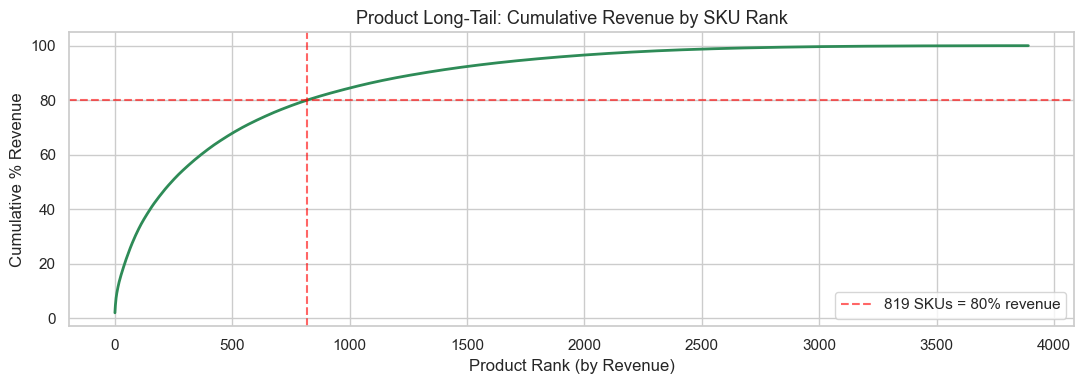

In [62]:
# Long-tail analysis
prod_clean_sorted = prod_clean.sort_values('Revenue', ascending=False).reset_index(drop=True)
prod_clean_sorted['CumRevPct'] = prod_clean_sorted['Revenue'].cumsum() / prod_clean_sorted['Revenue'].sum() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(prod_clean_sorted.index, prod_clean_sorted['CumRevPct'], color='seagreen', lw=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.6)
n80 = (prod_clean_sorted['CumRevPct'] <= 80).sum()
ax.axvline(n80, color='red', linestyle='--', alpha=0.6, label=f'{n80} SKUs = 80% revenue')
ax.set_title('Product Long-Tail: Cumulative Revenue by SKU Rank')
ax.set_xlabel('Product Rank (by Revenue)')
ax.set_ylabel('Cumulative % Revenue')
ax.legend()
plt.tight_layout()
# plt.savefig('../project/fig_product_longtail.png', dpi=100, bbox_inches='tight')
plt.show()

In [64]:
n80

819

In [66]:
len(prod_clean_sorted)

3892

In [ ]:
# 819 of 3892 SKUs account for 80% of revenue
# long tail distribution

## Basket / Order Analysis

=== Basket / Order level stats ===


,Revenue,Items,SKUs
count,18532.00,18532.00,18532.00
mean,480.87,278.86,20.93
std,1678.20,972.72,23.82
min,0.38,1.00,1.00
25%,158.04,74.00,6.00
50%,303.04,155.00,15.00
75%,471.84,291.00,27.00
max,168469.60,80995.00,541.00


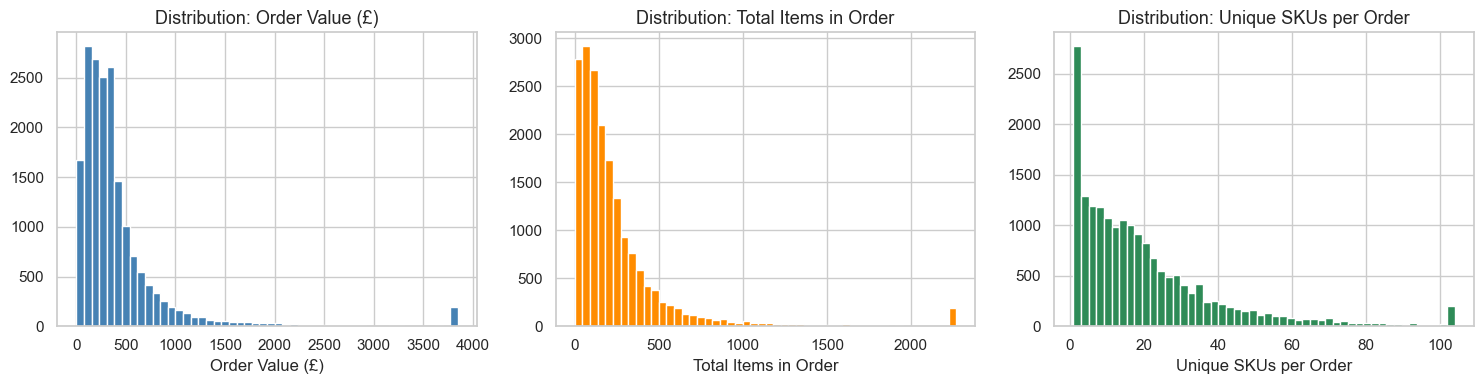

In [70]:
basket = df_clean.groupby('InvoiceNo').agg(
    Revenue  = ('Revenue','sum'),
    Items    = ('Quantity','sum'),
    SKUs     = ('StockCode','nunique'),
    Customer = ('CustomerID','first')
).reset_index()

print('=== Basket / Order level stats ===')
display(basket[['Revenue','Items','SKUs']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['Revenue','Items','SKUs'],
    ['Order Value (£)','Total Items in Order','Unique SKUs per Order'],
    ['steelblue','darkorange','seagreen']
):
    clip_val = basket[col].quantile(0.99)
    ax.hist(basket[col].clip(upper=clip_val), bins=50, color=color, edgecolor='white')
    ax.set_title(f'Distribution: {label}')
    ax.set_xlabel(label)

plt.tight_layout()
# plt.savefig('../project/fig_basket.png', dpi=100, bbox_inches='tight')
plt.show()

# RFM analysis (foundation for customer segmentation)
Recency, frequency, monetary

In [ ]:
## Can adjust segments accordingly

In [76]:
# compute RFM relative to the last date in the dataset
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

# score 1-5 (5 best)
rfm['R_score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segment labels
def segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal'
    if r >= 4 and f <= 2: return 'New/Promising'
    if r == 2 and f >= 3: return 'At Risk'
    if r <= 2 and f >= 4: return 'Cant Lose Them'
    if r <= 2 and f <= 2: return 'Lost'
    return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    Count     = ('CustomerID','count'),
    Avg_Recency   = ('Recency','mean'),
    Avg_Frequency = ('Frequency','mean'),
    Avg_Monetary  = ('Monetary','mean')
).round(1).sort_values('Count', ascending=False)

In [78]:
print('=== RFM Segments ===')
display(seg_summary)

=== RFM Segments ===


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,1139,13.3,10.0,5204.3
Lost,1065,217.9,1.1,487.7
Loyal,821,38.0,3.6,1651.3
Needs Attention,493,106.9,1.5,676.6
At Risk,442,114.4,3.6,1261.7
New/Promising,319,18.5,1.2,458.2
Cant Lose Them,59,233.5,4.9,1205.8


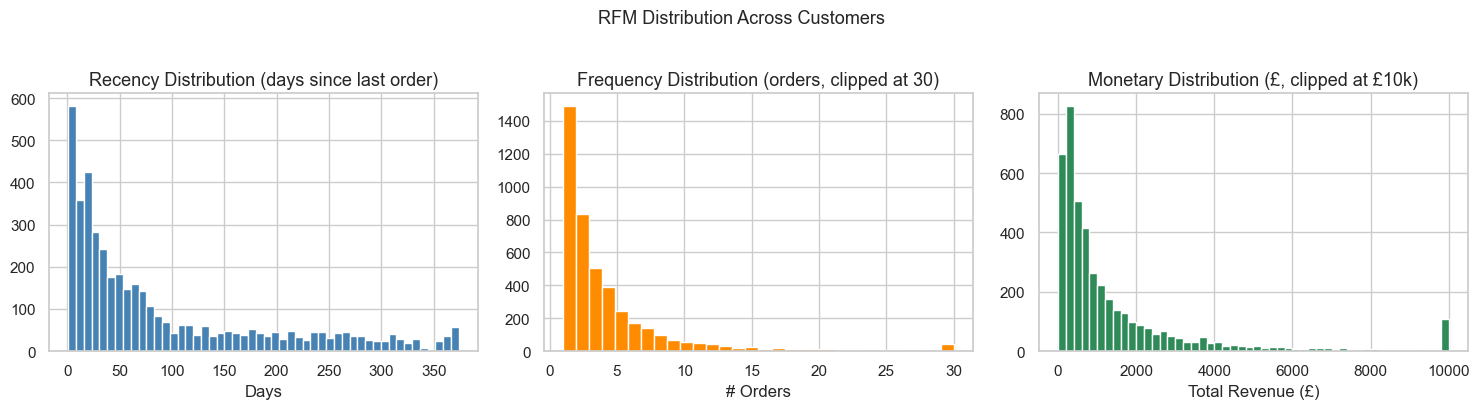

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'],   bins=50, color='steelblue',  edgecolor='white')
axes[0].set_title('Recency Distribution (days since last order)')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'].clip(upper=30), bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Frequency Distribution (orders, clipped at 30)')
axes[1].set_xlabel('# Orders')

axes[2].hist(rfm['Monetary'].clip(upper=10000), bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Monetary Distribution (£, clipped at £10k)')
axes[2].set_xlabel('Total Revenue (£)')

plt.suptitle('RFM Distribution Across Customers', y=1.02, fontsize=13)
plt.tight_layout()
# plt.savefig('../project/fig_rfm.png', dpi=100, bbox_inches='tight')
plt.show()

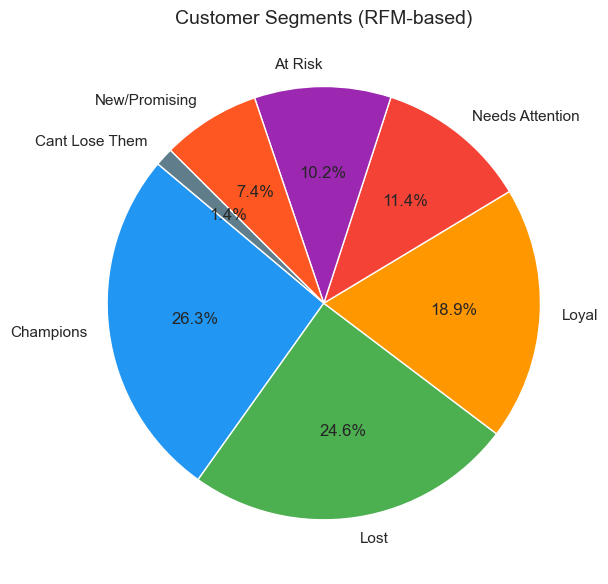

In [84]:
# Segment pie
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#FF5722','#607D8B']
seg_counts = rfm['Segment'].value_counts()
ax.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
       colors=colors[:len(seg_counts)], startangle=140)
ax.set_title('Customer Segments (RFM-based)', fontsize=14)
plt.tight_layout()
# plt.savefig('../project/fig_rfm_segments.png', dpi=100, bbox_inches='tight')
plt.show()

## Churn Label Construction

Since the dataset is for Dec 2010 – Dec 2011, we can define churn using a **training / label window** approach:

- **Observation window**: Dec 2010 – Aug 2011 (9 months) -- compute RFM features
- **Label window**: Sep 2011 – Dec 2011 (4 months) -- look at "did the customer purchase again?""
- **Churned** = No purchase in the label window
- **Active** = At least 1 purchase in the label window

In [89]:
obs_end    = pd.Timestamp('2011-08-31')
label_end  = pd.Timestamp('2011-12-09')

df_obs   = df_clean[df_clean['InvoiceDate'] <= obs_end]
df_label = df_clean[(df_clean['InvoiceDate'] > obs_end) & (df_clean['InvoiceDate'] <= label_end)]

# customers who were active during observation window
obs_customers = set(df_obs['CustomerID'].unique())

# customers who purchased again in label window
retained = set(df_label['CustomerID'].unique())

# Label
churn_df = pd.DataFrame({'CustomerID': list(obs_customers)})
churn_df['Churned'] = churn_df['CustomerID'].apply(lambda c: 0 if c in retained else 1)

churn_rate = churn_df['Churned'].mean()
print(f'Observation window customers: {len(churn_df):,}')
print(f'Churned (did not buy Sep–Dec 2011): {churn_df["Churned"].sum():,} ({churn_rate*100:.1f}%)')
print(f'Retained: {(churn_df["Churned"]==0).sum():,} ({(1-churn_rate)*100:.1f}%)')

Observation window customers: 3,312
Churned (did not buy Sep–Dec 2011): 1,356 (40.9%)
Retained: 1,956 (59.1%)


In [ ]:
# class balance is ok for binary classification (no extreme class imbalance)